<a href="https://colab.research.google.com/github/Manuel-rojas18/Talleres-POO/blob/main/PCA_%26_El_Metodo_del_Codo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://ai.studio/apps/c6aac927-8fcf-4bcf-b923-24bb4330f0f9

import React, { useState } from 'react';
import { PCAResult } from '../types';
import {
  Sparkles, CheckCircle2, XCircle, HelpCircle, BookOpen,
  Layers, Landmark, GraduationCap, Award
} from 'lucide-react';

interface TabInterpretationProps {
  pcaResult: PCAResult;
}

export const TabInterpretation: React.FC<TabInterpretationProps> = ({ pcaResult }) => {
  const { variables, eigenvectors, eigenvalues, varianceExplained } = pcaResult;

  // Mini quiz state for students
  const [selectedAnswers, setSelectedAnswers] = useState<Record<number, number>>({});
  const [showResults, setShowResults] = useState(false);

  const quizQuestions = [
    {
      question: '1. ¿Por qué PC1 explica el 53.3% de la varianza total mientras que PC6 solo el 2.0%?',
      options: [
        'Porque PC1 se calcula multiplicando por números más grandes arbitrariamente.',
        'Porque los autovalores se ordenan de mayor a menor y los autovectores buscan sucesivamente la dirección ortogonal de máxima dispersión remanente.',
        'Porque en el dataset original la variable Fertilidad era la primera columna de la tabla.',
      ],
      correct: 1,
      explanation:
        'Exacto. Por definición algebraica, el primer autovector maximiza la varianza proyectada. Los siguientes deben ser perpendiculares (ortogonales) y maximizar la varianza restante.',
    },
    {
      question: '2. En el Método del Codo (Scree Plot), ¿por qué seleccionamos los componentes antes del aplanamiento?',
      options: [
        'Porque después del codo la tasa de varianza explicada desciende a un nivel residual similar al ruido aleatorio (pedregal o scree).',
        'Porque una regla matemática prohíbe tener más de 2 o 3 componentes en cualquier dataset.',
        'Porque los autovalores después del codo siempre son exactamente iguales a cero.',
      ],
      correct: 0,
      explanation:
        'Correcto. Raymond Cattell propuso que la pendiente abrupta ("acantilado") contiene la señal sistemática, mientras que el codo marca la transición hacia los escombros planos de ruido no sistemático.',
    },
    {
      question: '3. ¿Qué sucedería si realizamos PCA sin estandarizar las variables (Z-score)?',
      options: [
        'El algoritmo arrojaría un error matemático de división por cero.',
        'Las variables con escalas numéricas más grandes (como % Católicos, de 0 a 100) acapararían erróneamente casi toda la varianza.',
        'El resultado sería exactamente idéntico, ya que PCA es invariante ante cualquier cambio de escala.',
      ],
      correct: 1,
      explanation:
        '¡Así es! Si una variable varía entre 0 y 1000 y otra entre 0 y 1, la primera tendrá una varianza miles de veces mayor y dominará el primer componente sin que signifique mayor relevancia real.',
    },
  ];

  return (
    <div className="space-y-8">
      {/* Historical & Sociological Context */}
      <section className="bg-white rounded-2xl border border-slate-200 p-6 sm:p-8 shadow-sm">
        <div className="mb-6">
          <div className="inline-flex items-center gap-1.5 px-3 py-1 rounded-full bg-indigo-500/10 text-indigo-700 text-xs font-semibold mb-2 border border-indigo-500/20">
            <Landmark className="w-3.5 h-3.5" />
            <span>Interpretación Sociológica Real (1888)</span>
          </div>
          <h2 className="text-xl sm:text-2xl font-bold text-slate-900">
            ¿Qué Significa Cada Componente en el Dataset Swiss?
          </h2>
          <p className="text-sm text-slate-600 mt-1 max-w-3xl leading-relaxed">
            Las matemáticas nos proporcionan autovalores y autovectores (magnitud y dirección de variabilidad), pero el verdadero valor de la ciencia de datos
            está en interpretar el significado sociológico e histórico de estos ejes.
          </p>
        </div>

        <div className="grid grid-cols-1 md:grid-cols-2 gap-6">
          {/* PC1 Card */}
          <div className="p-5 rounded-2xl border border-indigo-200 bg-gradient-to-br from-indigo-50/60 to-white">
            <div className="flex items-center justify-between mb-3">
              <span className="px-2.5 py-1 rounded-lg bg-indigo-600 text-white font-mono font-bold text-xs">
                PC1 (53.3% Varianza)
              </span>
              <span className="text-xs font-semibold text-indigo-900">Eje Principal</span>
            </div>
            <h3 className="text-base font-bold text-slate-900 mb-2">
              "Modernización &amp; Transición Demográfica vs. Ruralidad"
            </h3>
            <p className="text-xs text-slate-600 leading-relaxed mb-4">
              Separa a las provincias suizas según su grado de desarrollo educativo e industrial frente a la tradición agrícola.
            </p>
            <div className="space-y-2 text-xs">
              <div className="p-2.5 rounded-lg bg-white border border-indigo-100 flex items-center justify-between">
                <span className="text-slate-700">Polo Positivo (+):</span>
                <span className="font-semibold text-indigo-700">Alta Educación (+0.54), Alto Examen Militar (+0.57)</span>
              </div>
              <div className="p-2.5 rounded-lg bg-white border border-indigo-100 flex items-center justify-between">
                <span className="text-slate-700">Polo Negativo (-):</span>
                <span className="font-semibold text-rose-700">Alta Agricultura (-0.46), Alta Fertilidad (-0.48)</span>
              </div>
            </div>
          </div>

          {/* PC2 Card */}
          <div className="p-5 rounded-2xl border border-amber-200 bg-gradient-to-br from-amber-50/60 to-white">
            <div className="flex items-center justify-between mb-3">
              <span className="px-2.5 py-1 rounded-lg bg-amber-600 text-white font-mono font-bold text-xs">
                PC2 (19.8% Varianza)
              </span>
              <span className="text-xs font-semibold text-amber-900">Eje Ortogonal Secundario</span>
            </div>
            <h3 className="text-base font-bold text-slate-900 mb-2">
              "Fractura Cultural-Confesional &amp; Mortalidad Infantil"
            </h3>
            <p className="text-xs text-slate-600 leading-relaxed mb-4">
              Al ser ortogonal a PC1, captura la variación independiente de la educación: la filiación religiosa y las condiciones sanitarias de los recién nacidos.
            </p>
            <div className="space-y-2 text-xs">
              <div className="p-2.5 rounded-lg bg-white border border-amber-100 flex items-center justify-between">
                <span className="text-slate-700">Polo Positivo (+):</span>
                <span className="font-semibold text-amber-800">Catolicismo Alto (+0.70), Alta Mortalidad Infantil (+0.53)</span>
              </div>
              <div className="p-2.5 rounded-lg bg-white border border-amber-100 flex items-center justify-between">
                <span className="text-slate-700">Polo Negativo (-):</span>
                <span className="font-semibold text-blue-700">Cantones Protestantes de menor mortalidad infantil</span>
              </div>
            </div>
          </div>
        </div>
      </section>

      {/* Factor Loadings Table (Cargas Factoriales) */}
      <section className="bg-white rounded-2xl border border-slate-200 p-6 sm:p-8 shadow-sm">
        <h3 className="text-lg font-bold text-slate-900 mb-2">
          Tabla de Cargas Factoriales (Autovectores v)
        </h3>
        <p className="text-xs text-slate-600 mb-4">
          Pesos algebraicos de cada variable para formar las combinaciones lineales de los 3 primeros componentes.
        </p>

        <div className="overflow-x-auto rounded-xl border border-slate-200">
          <table className="w-full text-xs font-mono text-left">
            <thead className="bg-slate-100 text-slate-700 font-semibold border-b border-slate-200">
              <tr>
                <th className="p-3 font-sans">Variable Original</th>
                <th className="p-3 text-right">Peso en PC1</th>
                <th className="p-3 text-right">Peso en PC2</th>
                <th className="p-3 text-right">Peso en PC3</th>
                <th className="p-3 font-sans text-slate-600">Contribución Dominante</th>
              </tr>
            </thead>
            <tbody className="divide-y divide-slate-100">
              {variables.map((v, i) => {
                const w1 = eigenvectors[i][0];
                const w2 = eigenvectors[i][1];
                const w3 = eigenvectors[i][2];

                return (
                  <tr key={v.key} className="hover:bg-slate-50 transition-colors">
                    <td className="p-3 font-sans font-semibold text-slate-900">
                      {v.nameEs} <span className="text-slate-400 font-mono font-normal">({v.label})</span>
                    </td>
                    <td className={`p-3 text-right font-bold ${
                      Math.abs(w1) > 0.4 ? 'text-indigo-600 bg-indigo-50/30' : 'text-slate-600'
                    }`}>
                      {w1 >= 0 ? `+${w1.toFixed(3)}` : w1.toFixed(3)}
                    </td>
                    <td className={`p-3 text-right font-bold ${
                      Math.abs(w2) > 0.4 ? 'text-amber-600 bg-amber-50/30' : 'text-slate-600'
                    }`}>
                      {w2 >= 0 ? `+${w2.toFixed(3)}` : w2.toFixed(3)}
                    </td>
                    <td className={`p-3 text-right font-bold ${
                      Math.abs(w3) > 0.4 ? 'text-emerald-600 bg-emerald-50/30' : 'text-slate-600'
                    }`}>
                      {w3 >= 0 ? `+${w3.toFixed(3)}` : w3.toFixed(3)}
                    </td>
                    <td className="p-3 font-sans text-slate-600">
                      {Math.abs(w1) > Math.abs(w2) && Math.abs(w1) > Math.abs(w3)
                        ? 'Define fuertemente el Eje 1 (Desarrollo/Agricultura)'
                        : Math.abs(w2) > Math.abs(w3)
                        ? 'Define fuertemente el Eje 2 (Religión/Salud)'
                        : 'Aporta principalmente en el Eje 3 (Residual)'}
                    </td>
                  </tr>
                );
              })}
            </tbody>
          </table>
        </div>
      </section>

      {/* Interactive Self-Assessment Quiz */}
      <section className="bg-slate-900 text-white rounded-2xl p-6 sm:p-8 shadow-xl border border-slate-800">
        <div className="max-w-3xl">
          <div className="flex items-center gap-2 text-indigo-400 text-xs font-semibold uppercase tracking-wider mb-2">
            <BookOpen className="w-4 h-4" />
            <span>Comprobación Pedagógica de Aprendizaje</span>
          </div>
          <h3 className="text-xl font-bold text-white mb-2">
            Cuestionario Rápido: ¿Dominas los Conceptos de PCA y el Codo?
          </h3>
          <p className="text-xs text-slate-400 mb-6">
            Pon a prueba tu comprensión de la estandarización, los autovalores y la regla heurística del codo.
          </p>

          <div className="space-y-6">
            {quizQuestions.map((q, qIdx) => {
              const selected = selectedAnswers[qIdx];
              const isAnswered = selected !== undefined;
              const isCorrect = selected === q.correct;

              return (
                <div key={qIdx} className="bg-slate-800/80 p-5 rounded-xl border border-slate-700">
                  <h4 className="font-semibold text-sm text-slate-100 mb-3">{q.question}</h4>

                  <div className="space-y-2">
                    {q.options.map((opt, optIdx) => {
                      const isOptionSelected = selected === optIdx;
                      return (
                        <button
                          key={optIdx}
                          type="button"
                          onClick={() =>
                            setSelectedAnswers((prev) => ({ ...prev, [qIdx]: optIdx }))
                          }
                          className={`w-full text-left p-3 rounded-lg text-xs transition-all flex items-start gap-2.5 ${
                            isOptionSelected
                              ? 'bg-indigo-600 text-white ring-2 ring-indigo-400 font-medium'
                              : 'bg-slate-700/60 text-slate-300 hover:bg-slate-700 hover:text-white'
                          }`}
                        >
                          <span className="w-5 h-5 rounded-full bg-slate-800/80 flex items-center justify-center text-[10px] shrink-0 font-bold">
                            {String.fromCharCode(65 + optIdx)}
                          </span>
                          <span>{opt}</span>
                        </button>
                      );
                    })}
                  </div>

                  {isAnswered && (
                    <div className={`mt-3 p-3 rounded-lg text-xs flex items-start gap-2 ${
                      isCorrect ? 'bg-emerald-950/60 text-emerald-300 border border-emerald-800/60' : 'bg-rose-950/60 text-rose-300 border border-rose-800/60'
                    }`}>
                      {isCorrect ? (
                        <CheckCircle2 className="w-4 h-4 text-emerald-400 shrink-0 mt-0.5" />
                      ) : (
                        <XCircle className="w-4 h-4 text-rose-400 shrink-0 mt-0.5" />
                      )}
                      <div>
                        <span className="font-bold block mb-0.5">
                          {isCorrect ? '¡Respuesta Correcta!' : 'Respuesta Incorrecta'}
                        </span>
                        <p className="text-[11px] leading-relaxed">{q.explanation}</p>
                      </div>
                    </div>
                  )}
                </div>
              );
            })}
          </div>
        </div>
      </section>
    </div>
  );
};

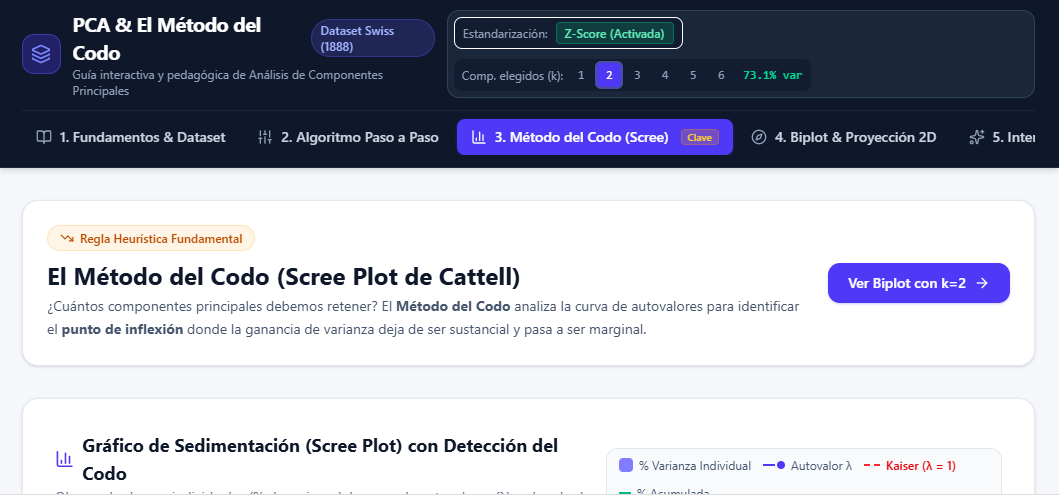

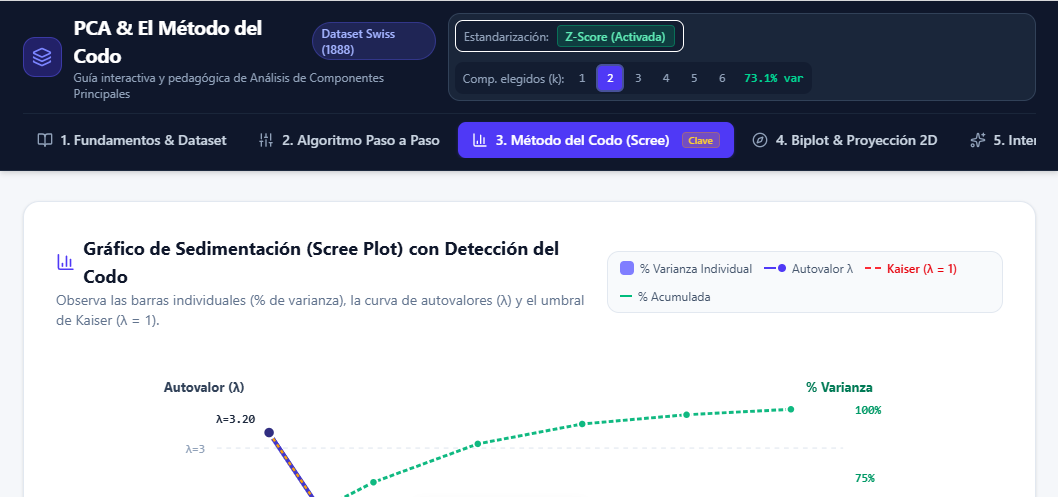

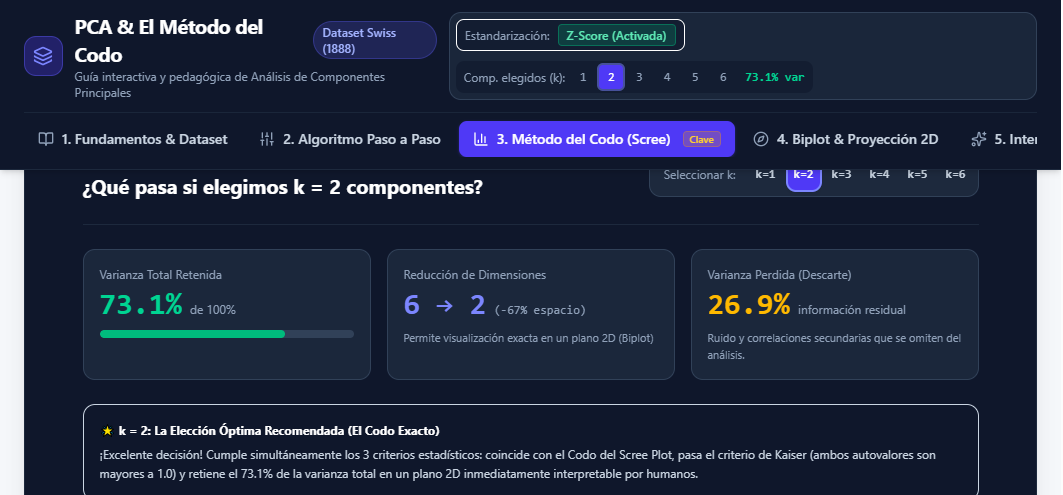